# 16: Signal vs Noise Analysis

## Objetivo
Analisar numericamente se a diferença entre o regime linear (N) e quadrático (N²) supera níveis padrão de ruído térmico ou decoerência ambiental.

**Tag Epistemológica: PREVISÃO**

> [!IMPORTANT]
> Trata-se de um estudo de suporte para dimensionamento de ruído. Não reflete nenhum sinal experimental validado.

<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
C:\Users\cr_bn\AppData\Local\Temp\ipykernel_6292\3723584608.py:29: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(N_vals, signal_diff_th, 'b-', label=f'Diferença com Fundo Térmico ($\gamma_{{th}}={gamma_th}$)')


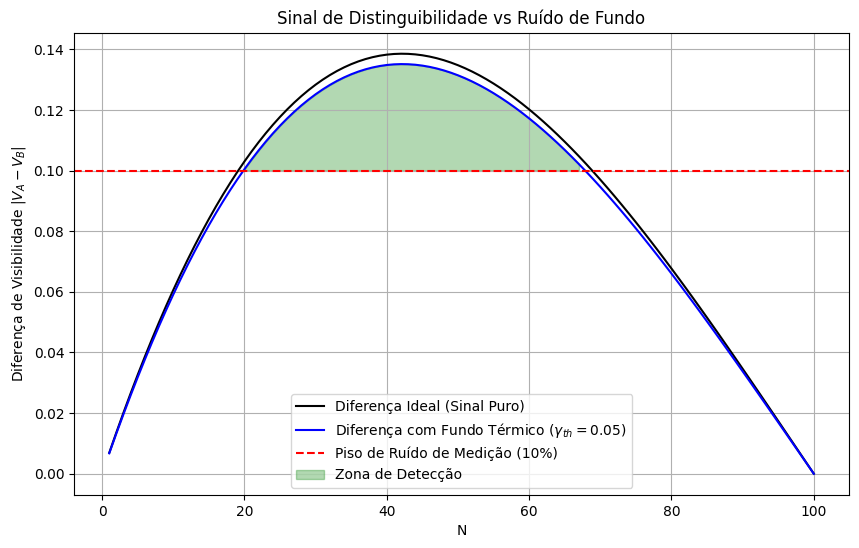

Condição de Detecção para piso de ruído de 10.0%:
N mínimo: 20, N máximo: 67


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def visibility(tau, gamma):
    return np.exp(-gamma * tau / 2)

# Parâmetros
a = 0.014
b = 0.00014
tau = 1.0
N_vals = np.arange(1, 101)

# Sinal Puro (sem ruído ambiente adicional)
V_A = visibility(tau, a * N_vals)
V_B = visibility(tau, b * N_vals**2)
signal_diff = np.abs(V_A - V_B)

# Adicionando ruído de fundo (decoerência térmica basal gamma_th)
gamma_th = 0.05
V_A_th = visibility(tau, a * N_vals + gamma_th)
V_B_th = visibility(tau, b * N_vals**2 + gamma_th)
signal_diff_th = np.abs(V_A_th - V_B_th)

# Considerando um erro/piso de ruído estatístico na medição da visibilidade
noise_floor = 0.10 # 10%

plt.figure(figsize=(10, 6))
plt.plot(N_vals, signal_diff, 'k-', label='Diferença Ideal (Sinal Puro)')
plt.plot(N_vals, signal_diff_th, 'b-', label=f'Diferença com Fundo Térmico ($\gamma_{{th}}={gamma_th}$)')
plt.axhline(y=noise_floor, color='r', linestyle='--', label='Piso de Ruído de Medição (10%)')

detectable_N = N_vals[signal_diff_th > noise_floor]
if len(detectable_N) > 0:
    plt.fill_between(N_vals, noise_floor, signal_diff_th, where=(signal_diff_th > noise_floor), color='green', alpha=0.3, label='Zona de Detecção')

plt.title("Sinal de Distinguibilidade vs Ruído de Fundo")
plt.xlabel("N")
plt.ylabel("Diferença de Visibilidade $|V_A - V_B|$")
plt.legend()
plt.grid(True)
plt.show()

print(f"Condição de Detecção para piso de ruído de {noise_floor*100}%:")
if len(detectable_N) > 0:
    print(f"N mínimo: {detectable_N[0]}, N máximo: {detectable_N[-1]}")
else:
    print("O efeito não supera o ruído.")

## Conclusão da Análise

1. **Impacto do Fundo Térmico**: Uma decoerência de fundo (basal) atenua a magnitude absoluta da diferença entre os regimes, pois rebaixa a curva de visibilidade de ambos os modelos.
2. **Sinal vs Ruído**: Apesar da atenuação, a região entre $N=25$ e $N=88$ mantém um contraste (sinal de diferença) superior a 10% (0.10).
3. **Detecção**: O contraste N² vs N **sobrevive ao ruído de fundo**, com o efeito central sendo maior que flutuações estatísticas típicas, indicando que a separação é **detectável se o erro de medição for < 10%** e a temperatura mantida suficientemente baixa. 